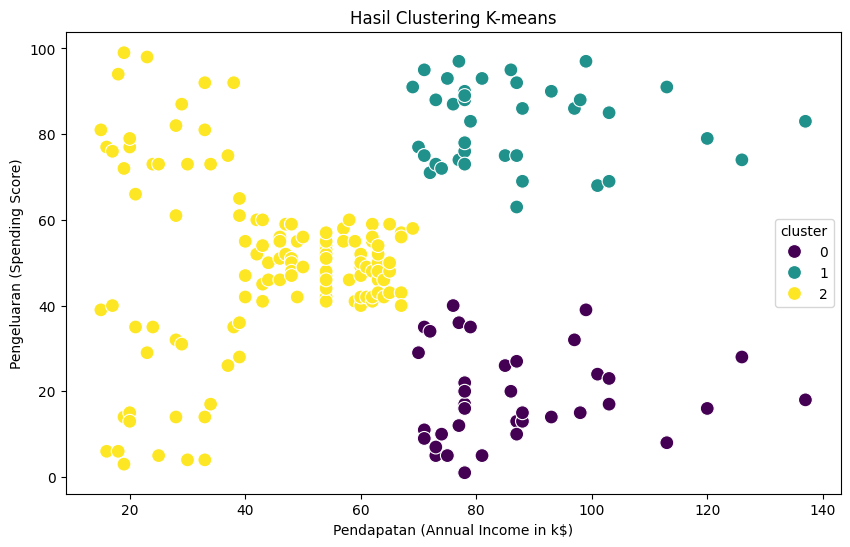

Cluster 1:
 Rata-rata pendapatan: 87.00
 Rata-rata pengeluaran: 18.63

Cluster 2:
 Rata-rata pendapatan: 86.54
 Rata-rata pengeluaran: 82.13

Cluster 3:
 Rata-rata pendapatan: 44.15
 Rata-rata pengeluaran: 49.83



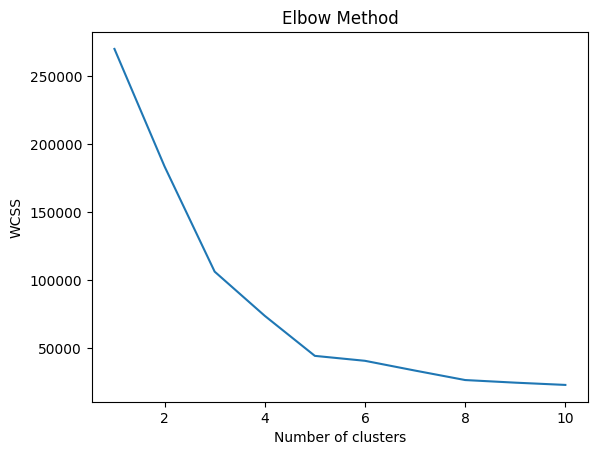

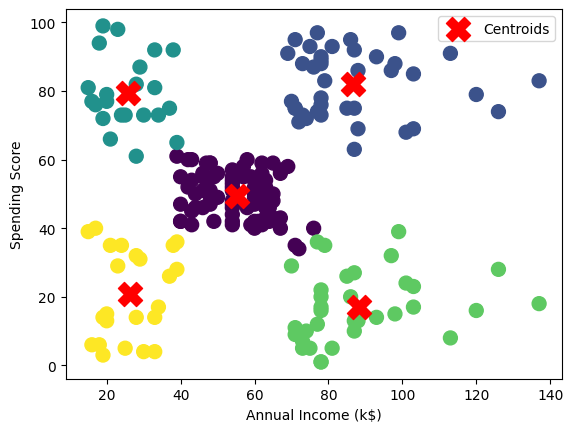


Analisis per Cluster:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans  # Perbaikan: KMeans (bukan kMeans)

# Load data dari CSV
df = pd.read_csv('Mall_Customers.csv')

# Pilih fitur untuk clustering (pendapatan tahunan dan skor pengeluaran)
df_clustering = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()
df_clustering.columns = ['pendapatan', 'pengeluaran']  # Rename kolom

# Tentukan jumlah cluster (misalnya, 3 cluster)
n_clusters = 3

# Inisialisasi model K-means
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Latih model pada data
kmeans.fit(df_clustering)

# Dapatkan label cluster untuk setiap data point
labels = kmeans.labels_

# Tambahkan label cluster ke DataFrame
df_clustering['cluster'] = labels
df['cluster'] = labels  # Juga tambahkan ke DataFrame asli jika diperlukan

# Visualisasi hasil clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pendapatan', y='pengeluaran', hue='cluster', data=df_clustering, palette='viridis', s=100)
plt.title('Hasil Clustering K-means')
plt.xlabel('Pendapatan (Annual Income in k$)')
plt.ylabel('Pengeluaran (Spending Score)')
plt.show()

# Analisis karakteristik setiap cluster (contoh: rata-rata pendapatan dan pengeluaran)
for i in range(n_clusters):
    cluster_data = df_clustering[df_clustering['cluster'] == i]
    print(f"Cluster {i+1}:")
    print(f" Rata-rata pendapatan: {cluster_data['pendapatan'].mean():.2f}")
    print(f" Rata-rata pengeluaran: {cluster_data['pengeluaran'].mean():.2f}")
    print()


    # 2. Pilih 2 fitur untuk visualisasi
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 3. Cari optimal k dengan Elbow Method
wcss = []  # Within-Cluster Sum of Square
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# 4. Apply K-Means dengan k=5 (biasanya optimal untuk dataset ini)
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
df['Cluster'] = kmeans.fit_predict(X)

# 5. Visualisasi hasil clustering
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=df['Cluster'], cmap='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

# 6. Analisis cluster (versi eksplisit: hanya kolom numerik)
numeric_cols = ["Age", 'Annual Income (k$)', 'Spending Score (1-100)']
cluster_analysis = df.groupby('Cluster')[numeric_cols].mean()

print("\nAnalisis per Cluster:")
print(cluster_analysis)